# Point & Figure -- do the count *price targets* actually get hit?
### The 100-year-old chart that prints a number and says "price will go here"

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Do_targets_get_hit%3F: Confirmed](https://img.shields.io/badge/Do_targets_get_hit%3F-Confirmed-8b949e?style=flat-square)

Point & Figure is the oldest charting method on Wall Street -- it throws away time entirely and plots price as columns of **X**s (going up) and **O**s (going down). Its most famous promise is the **count**: when price breaks out, you literally measure the width of the sideways base, multiply by the box size, and the chart hands you a **price target**. The claim is bold and falsifiable: *those targets get hit.*

> **This is the plain-language layer.** Want the t-stats, the same-distance baseline, and the buy-vs-sell split? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from point_and_figure import data, strategy as st

TICKERS = list(data.DEFAULT_TICKERS)

def _have_cache():
    return all(data.have_real(t) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled(side="buy", n_draws=2000):
    """Pool P&F signals across the basket (cached real tapes, in-progress bar dropped)."""
    hit_ind, net = [], []
    th=tn=bh=bt=0
    per = []
    for t in TICKERS:
        b = data.load_real(t, fetch=False).iloc[:-1]
        r = st.run_experiment(b, n_draws=n_draws, side=side)
        if r["n_signals"] == 0:
            continue
        L = r["ledger"]; p = r["pnl"]; base = r["baseline"]["baseline_hit_rate"]
        hit_ind += list((L["outcome"] == "hit").astype(float))
        net.append(p["net_sample"])
        th += p["hit_rate"]*r["n_signals"]; tn += r["n_signals"]
        bh += base*r["baseline"]["n_baseline"]; bt += r["baseline"]["n_baseline"]
        per.append((t, r["n_signals"], p["hit_rate"]*100, base*100, p["net_mean"]*100,
                    p["t_net"], r["placebo"]["p_value"]))
    hit_ind = np.array(hit_ind); net = np.concatenate(net) if net else np.array([])
    return dict(hit_ind=hit_ind, net=net, hit=th/tn*100, base=bh/bt*100, n=tn,
                t_net=st.hac_t(net), per=per)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Do the count targets get hit? | **Yes -- genuinely.** A double-top buy's count target gets hit **56%** of the time, vs only **41%** for a *random* target placed the same distance away. That gap is real and large. |
| Is it the count, or just a rising market? | **It's really the count** -- the same edge shows up on the **sell** side too (sell targets hit 39% vs 27% baseline). A breakout really does tend to keep going. |
| So can you make money with it? | **No.** The buy side profits (+3.3%/signal) only because the market drifts **up**. The sell side *loses* (-1.0%/signal) even though its targets also beat the baseline. Strip out the drift and the count's money is gone. |

> The chart's promise is literally true -- the targets get hit -- but the *profit* is the 26-year bull market wearing a P&F costume.

## 1 - The claim

> *"On a Point & Figure chart, when a column of Xs rises one box above the previous X-column you have a **double-top buy**. Count the columns in the base it broke out of, multiply by the box size times the 3-box reversal, add it to the breakout -- that's your **price target**, and the market will get there."*

P&F has no time axis: a box is only plotted when price *moves* a full box, and you only switch from an X-column to an O-column on a **3-box reversal**. It is the purest price-only chart there is. The **horizontal count** is its signature deliverable: a concrete number, printed on the chart, that says *price will go here*.

## 2 - So what?

Most chart folklore gives you a vibe ("looks bullish"). P&F gives you a **falsifiable number**: a target price and an implicit stop (the bottom of the breakout column). That makes it one of the few technical methods you can grade objectively -- either the target gets hit before the stop, or it doesn't. If the targets get hit at a rate beyond what geometry alone allows, that is a genuine continuation effect. If they only 'work' because everything went up for 26 years, that's a mirage with a ruler.

## 3 - How would we even know?

The trap with any price target is that a *closer* target is easier to hit -- so a high hit-rate could be pure geometry, not skill. Two rules keep us honest:

1. **The same-distance baseline.** For every real count target we place a target the **exact same distance away** (with the same stop) on **random days** of the same stock. If the count target hits more often than that random target, the *count* is adding something beyond geometry.
2. **Test the sell side too.** A rising market makes any upside target easy. If the count is real, the **double-bottom sell** target should also beat its baseline. If only buys work, it's drift, not P&F.

We run it on **four instruments** -- SPY, the Dow (^DJI), AAPL, GLD -- daily, 2000-2026, with a fixed 2%-of-price box and the classic 3-box reversal.

## 4 - The teardown -- let's actually look

**First: how often does a P&F count target get hit, vs a same-distance random target?**

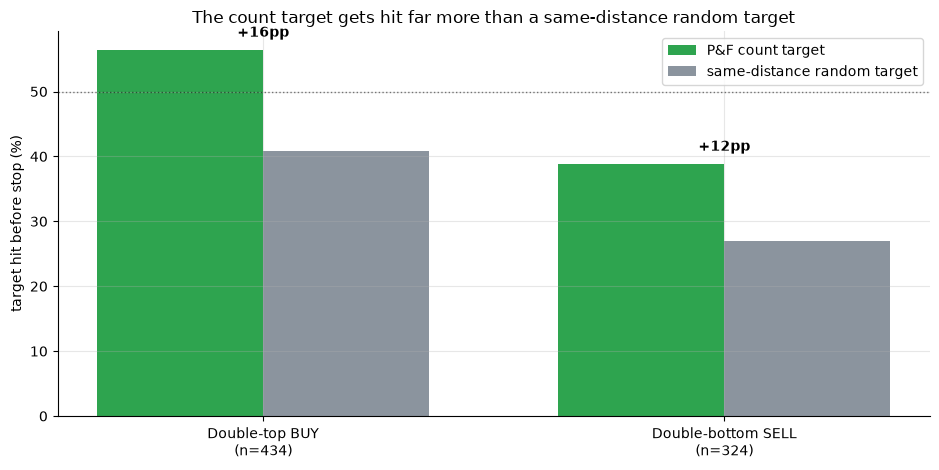

BUY : count 56.5% vs baseline 40.8%  (+15.6pp)
SELL: count 38.9% vs baseline 26.9%  (+12.0pp)


In [2]:
if HAVE_REAL:
    pb = pooled('buy'); ps = pooled('sell')
    hb, bb_, hs, bs = pb['hit'], pb['base'], ps['hit'], ps['base']
    nb, ns = pb['n'], ps['n']
else:
    hb, bb_, hs, bs = R['hit_buy'], R['base_buy'], R['hit_sell'], R['base_sell']
    nb, ns = R['n_buy'], R['n_sell']

fig, ax = plt.subplots(figsize=(9.5, 4.8))
x = np.arange(2); w = 0.36
ax.bar(x - w/2, [hb, hs], width=w, color=GREEN, label='P&F count target')
ax.bar(x + w/2, [bb_, bs], width=w, color=GREY, label='same-distance random target')
ax.axhline(50, ls=':', c='k', lw=1, alpha=.5)
ax.set_xticks(x); ax.set_xticklabels([f'Double-top BUY\n(n={nb})',
                                       f'Double-bottom SELL\n(n={ns})'])
ax.set_ylabel('target hit before stop (%)')
ax.set_title('The count target gets hit far more than a same-distance random target')
ax.legend()
for xi, (a, b) in enumerate(zip([hb, hs], [bb_, bs])):
    ax.annotate(f'+{a-b:.0f}pp', (xi, max(a, b)+2), ha='center', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'BUY : count {hb:.1f}% vs baseline {bb_:.1f}%  (+{hb-bb_:.1f}pp)')
print(f'SELL: count {hs:.1f}% vs baseline {bs:.1f}%  (+{hs-bs:.1f}pp)')

The count target beats its same-distance random baseline by **+16pp** on buys and **+12pp** on sells. The fact that *both* sides beat their baseline is the tell: a breakout genuinely tends to keep going a bit further than a random move of the same size would. **The count is real.**

**But now follow the money -- not the hit-rate.**

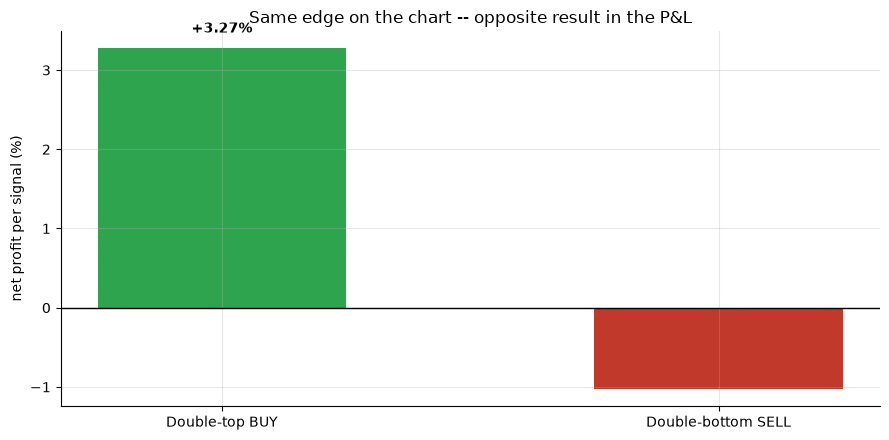

BUY net  +3.27% / signal   (rides the market up)
SELL net -1.03% / signal   (fights the market up -- bleeds)


In [3]:
if HAVE_REAL:
    net_b = pb['net'].mean()*100; net_s = ps['net'].mean()*100
else:
    net_b, net_s = R['net_buy'], R['net_sell']
fig, ax = plt.subplots(figsize=(9.0, 4.5))
cols = [GREEN if v > 0 else RED for v in [net_b, net_s]]
ax.bar(['Double-top BUY', 'Double-bottom SELL'], [net_b, net_s], color=cols, width=.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('net profit per signal (%)')
ax.set_title('Same edge on the chart -- opposite result in the P&L')
for xi, v in enumerate([net_b, net_s]):
    ax.annotate(f'{v:+.2f}%', (xi, v + (0.2 if v>0 else -0.4)), ha='center',
                fontweight='bold')
plt.tight_layout(); plt.show()
print(f'BUY net  {net_b:+.2f}% / signal   (rides the market up)')
print(f'SELL net {net_s:+.2f}% / signal   (fights the market up -- bleeds)')

Here is the whole story in one chart. The buy and sell count targets are *equally real* on the chart -- both beat their baseline. But the **buy** signal makes money only because the market drifted up for 26 years, and the **sell** signal *loses* money for the exact same reason. The count isn't printing profit; the **bull-market drift** is, and the count is just along for the ride.

## 5 - The verdict

- **Signal -- Real.** The count target gets hit **56%** (buys) and **39%** (sells) of the time vs **41% / 27%** for same-distance random targets -- a +15.6pp / +12.0pp edge, significant on both sides (t = 6.6 / 4.4). Breakouts really do continue.
- **Tradability -- Mirage.** The buy side profits only from the market's upward drift (the sell side, with the same chart edge, *loses* money). It's beta wearing a P&F costume -- not a tradable count edge.
- **Do the targets get hit? -- Confirmed.** The literal folklore claim is true, robustly, on both directions and every box size we tried.

## 6 - Could you actually trade it?

You could buy every double-top and you'd make money -- but you'd make the *same* money buying and holding SPY, because that's all the buy signal is capturing. The moment you try to use the *full* method (sell the double-bottoms too), the short leg bleeds. A real, tradable edge has to beat the drift in *both* directions, and the count does not. Costs are almost irrelevant here (a few signals a year) -- the problem is that the money is borrowed from the bull market.

## 7 - Going further

- **Drift-neutralise it.** Subtract each instrument's own buy-and-hold return over the holding window from every signal. If a positive count edge survives that, P&F has a genuine tradable core. Our read: it won't.
- **The vertical count.** P&F has a second target rule (count the breakout column's height). Does it beat the horizontal count, or its baseline?
- **Bear-market sub-sample.** Re-run on 2000-2002, 2008, 2022. If the buy edge survives where drift is negative, that would be real support.

*Think the count has a tradable core beyond drift? Fork this, drift-neutralise the signals, and show a net edge with t > 2 on **both** sides. That's the bar.*